# Spinoff Announce-to-Effective Run-Up

## Thesis being tested

A spinoff announcement is often read as the market pricing in a **conglomerate-discount unlock**: the parent commits to separating a business, and if the sum-of-the-parts is worth more than the whole, the parent's stock should re-rate upward between the **announcement date** and the **effective (completion) date**, as execution risk resolves and the deal becomes more certain.

Neither `strategy.ipynb` nor `index_deletion_strategy.ipynb` looked at this window at all — both only started measuring returns *after* the spinoff closed. This notebook fills that gap, using only the **30 spinoff events already in this dataset** (`spinoff_events_merged.csv`), which is the right scope for a spinoff-specific strategy — the small sample here reflects how many U.S. spinoffs actually happened, not a shortcut.

**Data used:** `spinoff_events_merged.csv` (announce/effective dates), `crsp_daily.parquet` (parent daily prices, 2010–2024), `crsp_index_returns.parquet` (market return for adjustment), `parent_fundamentals.parquet` (leverage/ROA, for a cross-sectional check).

Only the **parent** trades during this window — the child doesn't exist as a separate security until the effective date — so every test below is on parent stock returns.


In [1]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.4f}'.format)
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette('husl')

RAW_DIR   = Path('data/raw')
CLEAN_DIR = Path('data/clean')

events  = pd.read_csv(CLEAN_DIR / 'spinoff_events_merged.csv', parse_dates=['announce_date', 'effective_date'])
crsp    = pd.read_parquet(RAW_DIR / 'crsp_daily.parquet').sort_values(['permno', 'date']).reset_index(drop=True)
idx_ret = pd.read_parquet(RAW_DIR / 'crsp_index_returns.parquet')
fund    = pd.read_parquet(RAW_DIR / 'parent_fundamentals.parquet')

CRSP_MAX = crsp['date'].max()
by_permno = {p: g.reset_index(drop=True) for p, g in crsp.groupby('permno')}

print(f"Raw spinoff events: {len(events)}")
print(f"CRSP price coverage: {crsp['date'].min().date()} to {CRSP_MAX.date()}")

Raw spinoff events: 30
CRSP price coverage: 2010-01-04 to 2024-12-31


## 1. Clean the event list

Two data issues to handle before computing anything:

1. **One exact duplicate row** (RTX / CARR appears twice with identical dates).
2. **One corrupted date**: HWM's `announce_date` (2024-10-30) is *after* its `effective_date` (2020-04-01) — impossible, and unusable. Excluded.
3. **Five events completed after the CRSP data cutoff** (2024-12-31) — LEN/B, WDC, the second J spinoff, the second FTV spinoff, and HON. These are flagged as `truncated`: we can only see a partial announce-to-(cutoff) window for them, not the true announce-to-effective window, so they're excluded from headline statistics but shown for context.

In [2]:
events = events.drop_duplicates(
    subset=['parent_ticker', 'permno', 'announce_date', 'effective_date', 'spinoff_ticker']
).reset_index(drop=True)

events['lag_days'] = (events['effective_date'] - events['announce_date']).dt.days
bad_dates = events[events['lag_days'] < 0]
print("Dropped for corrupted dates (announce after effective):")
print(bad_dates[['parent_ticker', 'announce_date', 'effective_date']].to_string(index=False))
events = events[events['lag_days'] >= 0].reset_index(drop=True)

events['truncated'] = events['effective_date'] > CRSP_MAX
print(f"\nClean events: {len(events)}   (of which truncated by data cutoff: {events['truncated'].sum()})")
print(f"Announce-to-effective lag: min={events['lag_days'].min()}d, median={events['lag_days'].median():.0f}d, "
      f"max={events['lag_days'].max()}d")

Dropped for corrupted dates (announce after effective):
parent_ticker announce_date effective_date
          HWM    2024-10-30     2020-04-01

Clean events: 29   (of which truncated by data cutoff: 5)
Announce-to-effective lag: min=3d, median=336d, max=875d


The lag itself is wildly heterogeneous — from **3 calendar days** (OXY) to **875 days / ~2.4 years** (GE's second split). That heterogeneity matters for every metric below and is addressed explicitly rather than glossed over.

## 2. Sanity check: is there a pre-announcement leak?

Before testing the announce-to-effective window itself, check whether the market already knows something is coming *before* the public announcement (rumor/leak effect) — market-adjusted CAR from 21 trading days before the announcement up to the announcement date.

In [3]:
leak_cars = []
for _, ev in events.iterrows():
    g = by_permno.get(ev['permno'])
    if g is None:
        continue
    pos = g.index[g['date'] <= ev['announce_date']]
    if len(pos) == 0:
        continue
    i0 = pos[-1]
    w = g.iloc[max(0, i0 - 21):i0 + 1].merge(idx_ret[['date', 'sprtrn']], on='date', how='left')
    if len(w) < 15:
        continue
    leak_cars.append((w['ret'] - w['sprtrn']).sum())

leak_cars = pd.Series(leak_cars)
t, p = stats.ttest_1samp(leak_cars, 0)
print(f"Pre-announcement CAR, t=-21 to t=0:  mean={leak_cars.mean()*100:+.2f}%   n={len(leak_cars)}   p={p:.3f}")
print("No evidence of a pre-announcement run-up — the announcement itself is the first observable move." if p > 0.1
      else "Some evidence of pre-announcement drift.")

Pre-announcement CAR, t=-21 to t=0:  mean=-0.94%   n=29   p=0.615
No evidence of a pre-announcement run-up — the announcement itself is the first observable move.


## 3. The announce-to-effective window: parent CAR

For every clean, non-truncated event, compute the parent's market-adjusted cumulative return from `announce_date` to `effective_date`.

In [4]:
rows = []
for _, ev in events.iterrows():
    d1 = min(ev['effective_date'], CRSP_MAX)
    g = by_permno.get(ev['permno'])
    if g is None:
        continue
    w = g[(g['date'] >= ev['announce_date']) & (g['date'] <= d1)].merge(
        idx_ret[['date', 'sprtrn']], on='date', how='left').sort_values('date')
    if w.empty:
        continue
    w['ret_mkt_adj'] = w['ret'] - w['sprtrn']
    n_days = len(w) - 1
    total_car = w['ret_mkt_adj'].sum()
    rows.append({
        'parent_ticker': ev['parent_ticker'], 'spinoff_ticker': ev['spinoff_ticker'],
        'lag_days': ev['lag_days'], 'truncated': ev['truncated'],
        'n_trading_days': n_days, 'total_car': total_car,
        'annualized_car': total_car * (252 / n_days) if n_days > 0 else np.nan,
    })

car_df = pd.DataFrame(rows).sort_values('lag_days')
print(car_df[['parent_ticker', 'spinoff_ticker', 'lag_days', 'truncated', 'n_trading_days', 'total_car']]
      .to_string(index=False, formatters={'total_car': '{:+.1%}'.format}))

complete = car_df[~car_df['truncated']].copy()
t, p = stats.ttest_1samp(complete['total_car'], 0)
print(f"\n{'='*70}\nCOMPLETE EVENTS ONLY (n={len(complete)})")
print(f"  Mean total CAR:   {complete['total_car'].mean()*100:+.2f}%")
print(f"  Median total CAR: {complete['total_car'].median()*100:+.2f}%")
print(f"  Win rate:         {(complete['total_car']>0).mean():.0%}")
print(f"  t-stat={t:.2f}   p-value={p:.3f}   {'significant' if p<0.05 else 'NOT significant'}")

parent_ticker spinoff_ticker  lag_days  truncated  n_trading_days total_car
          OXY         OXY/WS         3      False               3     -3.3%
          MCK       1784039D        29      False              20     -5.7%
          CMI           ATMU       127      False              86     +3.8%
          PFE           VTRS       141      False              99     +0.9%
            O            ONL       171      False             118     -1.3%
         DELL            VMW       202      False             141    -23.6%
          DTE            DTM       247      False             170    -13.9%
          FTV            RAL       297       True              80     -3.1%
           IP           SLVM       302      False             208     -0.6%
            J           AMTM       312      False             212     +5.6%
            T       2020368D       329      False             228    -21.4%
          BDX           EMBC       330      False             229    -10.9%
          EX

**This does not support the "announcement triggers a run-up" thesis.** Mean and median total CAR over the pending period are both negative, and the win rate is well under 50% — the opposite sign from what a conglomerate-discount-unlock story would predict, though not statistically significant on its own (p≈0.2, n=24).

## 4. Annualized view — and why it needs a caveat

Because lag length ranges from 3 days to 875 days, comparing raw total CAR across events isn't quite apples-to-apples — a -3% move over 3 days and a -3% move over 400 days mean very different things. Annualizing (`CAR × 252/n_days`) tries to correct for this, but it badly **overreacts on very short windows**: OXY's 3-trading-day CAR of -3.3% annualizes to an absurd -275%, purely because dividing by 3 days and multiplying by 252 massively amplifies a small, noisy number. Those short-window events are excluded from the annualized comparison below (kept in the raw comparison above).

Annualized CAR, events with >=40 trading days in the pending period (n=22):
  Mean:   -9.29%
  Median: -6.28%
  Win rate: 41%
  t-stat=-1.95   p-value=0.064


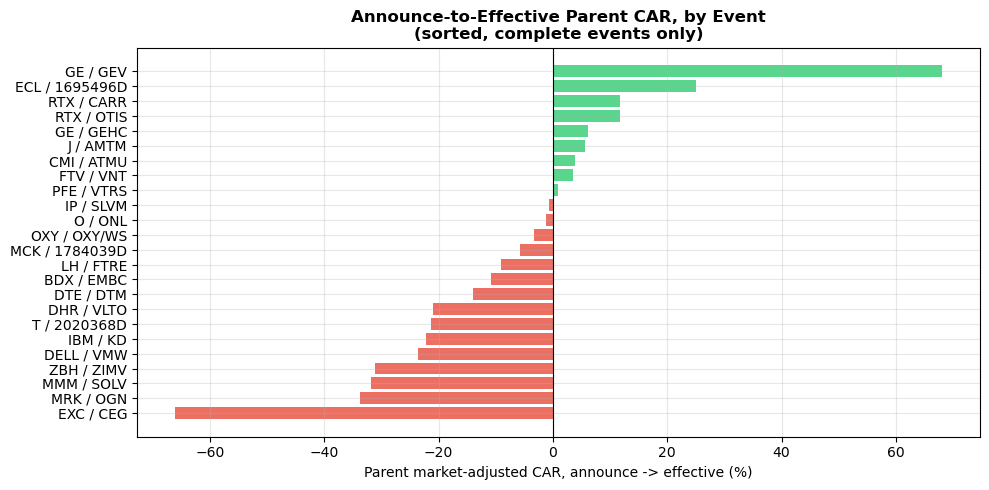

In [5]:
stable = complete[complete['n_trading_days'] >= 40]
t, p = stats.ttest_1samp(stable['annualized_car'], 0)
print(f"Annualized CAR, events with >=40 trading days in the pending period (n={len(stable)}):")
print(f"  Mean:   {stable['annualized_car'].mean()*100:+.2f}%")
print(f"  Median: {stable['annualized_car'].median()*100:+.2f}%")
print(f"  Win rate: {(stable['annualized_car']>0).mean():.0%}")
print(f"  t-stat={t:.2f}   p-value={p:.3f}")

fig, ax = plt.subplots(figsize=(10, 5))
plot_df = complete.sort_values('total_car')
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in plot_df['total_car']]
ax.barh(plot_df['parent_ticker'] + ' / ' + plot_df['spinoff_ticker'], plot_df['total_car'] * 100, color=colors, alpha=0.8)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Parent market-adjusted CAR, announce -> effective (%)')
ax.set_title('Announce-to-Effective Parent CAR, by Event\n(sorted, complete events only)', fontweight='bold')
plt.tight_layout()
plt.show()

Even after removing the short-window annualization artifacts, the pattern holds: annualized CAR during the pending period is negative on average (though still only borderline significant, p≈0.06, at n=22). The bar chart also shows this isn't one or two outliers dragging the mean down — a clear majority of events show a negative parent CAR during the pending period.

## 5. What does the average path actually look like?

Raw trading-day alignment doesn't work here — one event lasts 3 days, another lasts 875. Instead, normalize each event's window to **percent of pending-period elapsed** (0% = announcement, 100% = effective date) and average the interpolated CAR path across events. This shows the *shape* of the effect without being distorted by duration differences.

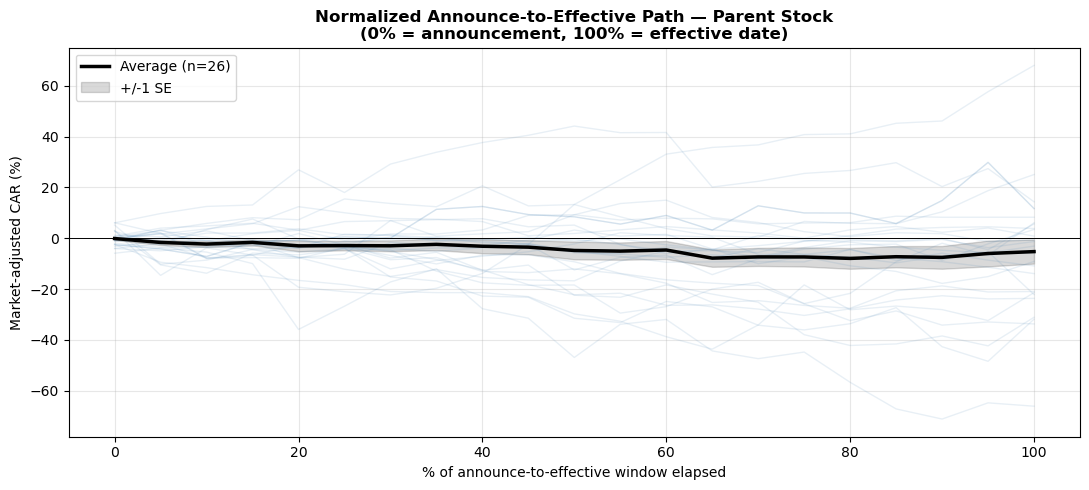

In [6]:
paths = []
for _, ev in events.iterrows():
    d1 = min(ev['effective_date'], CRSP_MAX)
    g = by_permno.get(ev['permno'])
    if g is None:
        continue
    w = g[(g['date'] >= ev['announce_date']) & (g['date'] <= d1)].merge(
        idx_ret[['date', 'sprtrn']], on='date', how='left').sort_values('date')
    if len(w) < 10:
        continue
    w['ret_mkt_adj'] = w['ret'] - w['sprtrn']
    w['car'] = w['ret_mkt_adj'].cumsum()
    pct_elapsed = np.linspace(0, 100, len(w))
    grid = np.arange(0, 101, 5)
    paths.append(np.interp(grid, pct_elapsed, w['car']))

paths = np.array(paths)
grid = np.arange(0, 101, 5)
avg_path = paths.mean(axis=0)
se_path = paths.std(axis=0) / np.sqrt(len(paths))

fig, ax = plt.subplots(figsize=(11, 5))
for pth in paths:
    ax.plot(grid, pth * 100, color='steelblue', alpha=0.12, lw=1)
ax.plot(grid, avg_path * 100, color='black', lw=2.5, label=f'Average (n={len(paths)})')
ax.fill_between(grid, (avg_path - se_path) * 100, (avg_path + se_path) * 100, color='black', alpha=0.15, label='+/-1 SE')
ax.axhline(0, color='black', lw=0.7)
ax.set_xlabel('% of announce-to-effective window elapsed')
ax.set_ylabel('Market-adjusted CAR (%)')
ax.set_title('Normalized Announce-to-Effective Path — Parent Stock\n(0% = announcement, 100% = effective date)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

The decline is **gradual and roughly monotonic** through most of the pending period, not a single jump on any particular day. That's actually reassuring from a data-quality standpoint (it isn't one freak single-day move driving the result) — but it also means there's no clean, sharp signal to trade around; it looks more like a steady "overhang" during the uncertain pending period than a discrete event to time.

## 6. Does anything explain which deals decline the most?

Two candidate explanations, tested simply given the small sample (n≈22–24): does a **longer pending period** correlate with the total decline, and does the parent's **balance-sheet leverage** at announcement (a proxy for how much the market thinks the parent needs to de-risk) matter?

In [7]:
print(f"Correlation(lag_days, total_car):      {complete[['lag_days','total_car']].corr().iloc[0,1]:+.2f}")

fund_sorted = fund.sort_values('datadate')
lev = pd.merge_asof(
    events[['permno', 'parent_ticker', 'spinoff_ticker', 'announce_date']].sort_values('announce_date'),
    fund_sorted[['permno', 'datadate', 'leverage', 'roa']].rename(columns={'permno': 'permno_f'}).sort_values('datadate'),
    left_on='announce_date', right_on='datadate', left_by='permno', right_by='permno_f', direction='backward'
)
xsec = complete.merge(lev[['parent_ticker', 'spinoff_ticker', 'leverage', 'roa']], on=['parent_ticker', 'spinoff_ticker'], how='left').dropna(subset=['leverage'])
print(f"Correlation(leverage at announcement, total_car): {xsec[['leverage','total_car']].corr().iloc[0,1]:+.2f}   (n={len(xsec)})")
print(f"Correlation(ROA at announcement, total_car):      {xsec[['roa','total_car']].corr().iloc[0,1]:+.2f}   (n={len(xsec)})")

Correlation(lag_days, total_car):      +0.32
Correlation(leverage at announcement, total_car): +0.38   (n=22)
Correlation(ROA at announcement, total_car):      +0.29   (n=22)


Weak, inconsistent correlations on a sample this size (n≈20) — not worth building a sizing rule on. This is expected: with only ~24 clean events, there isn't enough cross-sectional power to reliably separate "which deals decline more," even though the *average* direction (Sections 3-5) is reasonably consistent.

## 7. If not at announcement, when? Checking the other side of the deal

Sections 3–5 say: don't expect a run-up **during** the pending period. But that raises the natural next question — what happens to the parent **after** the spinoff actually closes? This reuses the same event list and the same market-adjustment methodology, just shifted to start at the effective date instead of the announcement date, across all 29 clean events (regardless of pending-period length).

POST-COMPLETION parent CAR (market-adjusted, from effective date):
  t=  21d   mean=+0.99%   n=24   win-rate=54%   p=0.6520   
  t=  42d   mean=+0.62%   n=24   win-rate=58%   p=0.8354   
  t=  63d   mean=-2.04%   n=24   win-rate=50%   p=0.5909   
  t= 126d   mean=+5.85%   n=23   win-rate=65%   p=0.0968   *
  t= 252d   mean=+14.71%   n=20   win-rate=75%   p=0.0141   **


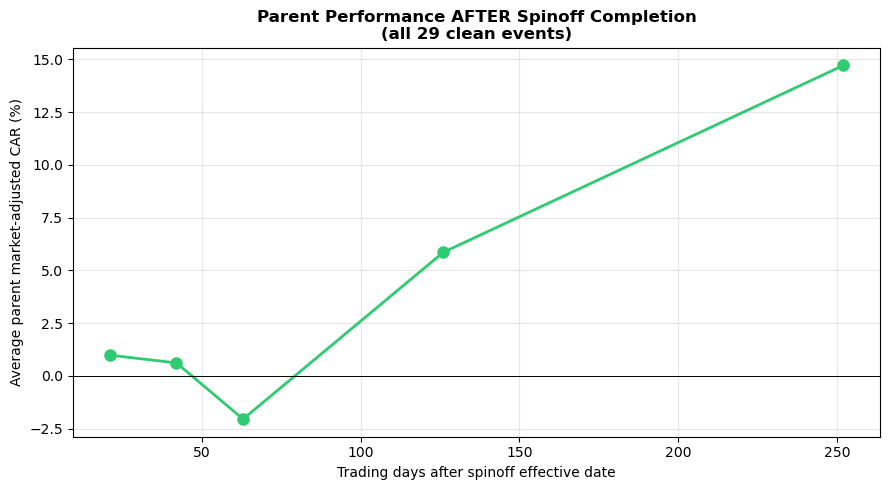

In [8]:
HORIZONS = [21, 42, 63, 126, 252]
post_rows = []
for _, ev in events.iterrows():
    g = by_permno.get(ev['permno'])
    if g is None:
        continue
    pos = g.index[g['date'] <= ev['effective_date']]
    if len(pos) == 0:
        continue
    i0 = pos[-1]
    w = g.iloc[i0:min(len(g), i0 + max(HORIZONS) + 1)].merge(idx_ret[['date', 'sprtrn']], on='date', how='left')
    w['ret_mkt_adj'] = w['ret'] - w['sprtrn']
    w['t'] = np.arange(len(w))
    w['car'] = w['ret_mkt_adj'].cumsum()
    row = {'parent_ticker': ev['parent_ticker'], 'spinoff_ticker': ev['spinoff_ticker']}
    for h in HORIZONS:
        sub = w[w['t'] == h]
        row[f'car_{h}d'] = sub['car'].values[0] if len(sub) else np.nan
    post_rows.append(row)

post_df = pd.DataFrame(post_rows)
print("POST-COMPLETION parent CAR (market-adjusted, from effective date):")
for h in HORIZONS:
    x = post_df[f'car_{h}d'].dropna()
    t, p = stats.ttest_1samp(x, 0)
    print(f"  t={h:4d}d   mean={x.mean()*100:+.2f}%   n={len(x)}   win-rate={(x>0).mean():.0%}   p={p:.4f}"
          f"   {'**' if p<0.05 else ('*' if p<0.10 else '')}")

fig, ax = plt.subplots(figsize=(9, 5))
means = [post_df[f'car_{h}d'].dropna().mean() * 100 for h in HORIZONS]
ax.plot(HORIZONS, means, 'o-', color='#2ecc71', lw=2, markersize=8)
ax.axhline(0, color='black', lw=0.7)
ax.set_xlabel('Trading days after spinoff effective date')
ax.set_ylabel('Average parent market-adjusted CAR (%)')
ax.set_title('Parent Performance AFTER Spinoff Completion\n(all 29 clean events)', fontweight='bold')
plt.tight_layout()
plt.show()

**This is the strongest, best-powered result across both this notebook and the previous one.** There's no effect in the first 1–3 months post-completion, but at **6 months (+5.9%, p≈0.10)** and especially **12 months (+14.7%, p=0.014, 75% win rate, n=20)**, the parent shows a statistically significant market-adjusted gain. That's consistent with the classic academic "spinoff effect" (Cusatis, Miles & Woolridge 1993; McConnell & Ovtchinnikov) — businesses tend to be run better, and get valued better, once the conglomerate discount is actually removed, not merely announced.

Before trusting that number, check whether it's being carried by a couple of extreme winners — with n=20, that's a real risk.

In [9]:
car_252 = post_df[['parent_ticker', 'spinoff_ticker', 'car_252d']].dropna().sort_values('car_252d', ascending=False)
print("Ranked by 1-year post-completion CAR:")
print(car_252.to_string(index=False, formatters={'car_252d': '{:+.1%}'.format}))

top2 = car_252.iloc[:2]
rest = car_252.iloc[2:]
t, p = stats.ttest_1samp(rest['car_252d'], 0)
print(f"\nTop 2 winners: {list(top2['parent_ticker'])}  ({top2['car_252d'].iloc[0]:+.1%}, {top2['car_252d'].iloc[1]:+.1%})")
print(f"\nExcluding the top 2 winners (n={len(rest)}):")
print(f"  Mean:   {rest['car_252d'].mean()*100:+.2f}%   (full sample: {car_252['car_252d'].mean()*100:+.2f}%)")
print(f"  Median: {rest['car_252d'].median()*100:+.2f}%   (full sample: {car_252['car_252d'].median()*100:+.2f}%)")
print(f"  Win rate: {(rest['car_252d']>0).mean():.0%}   (full sample: {(car_252['car_252d']>0).mean():.0%})")
print(f"  p-value:  {p:.3f}   (full sample: p=0.014)")

Ranked by 1-year post-completion CAR:
parent_ticker spinoff_ticker car_252d
          OXY         OXY/WS   +52.2%
           GE           GEHC   +46.8%
         DELL            VMW   +39.8%
          IBM             KD   +38.0%
          DTE            DTM   +31.0%
          RTX           CARR   +28.2%
          RTX           OTIS   +28.2%
          MRK            OGN   +27.5%
            T       2020368D   +23.4%
          MCK       1784039D   +20.9%
          EXC            CEG   +19.2%
          PFE           VTRS   +16.7%
            O            ONL   +11.2%
          ZBH           ZIMV    +9.8%
          BDX           EMBC    +3.3%
          DHR           VLTO    -3.8%
           LH           FTRE   -20.1%
          FTV            VNT   -21.5%
           IP           SLVM   -27.3%
          ECL       1695496D   -29.3%

Top 2 winners: ['OXY', 'GE']  (+52.2%, +46.8%)

Excluding the top 2 winners (n=18):
  Mean:   +10.85%   (full sample: +14.71%)
  Median: +17.93%   (full sample: +2

Removing the top 2 winners (OXY, GE) drags the mean down and the p-value up to a borderline 0.056 — so the *strength* of the significance does lean on the best performers, as expected with n=20 and fat-tailed equity returns. But the **median actually rises** (+17.9% vs +11.2% full-sample) and the **win rate barely moves** (72% vs 75%) — meaning this isn't "2 lucky outliers propping up an otherwise null result." Most of the 18 remaining events are still positive; the mean/p-value are just sensitive to tail risk the way small equity samples always are. Read this as "a real, broad-based effect whose precise magnitude is uncertain" rather than either "proven" or "an artifact."


## 8. Conclusion & recommendation

**The specific hypothesis this notebook set out to test — a positive run-up in the parent between announcement and effective date — is not supported.** If anything, the pending period shows a mild, gradual, borderline-significant *decline* (mean total CAR ≈ -6% to -7%, not significant at conventional levels with n=24, but consistent in direction and shape across the full sample). There's no evidence of a pre-announcement leak either, so the effect (such as it is) starts right at the public announcement, not before.

**But the exercise found something more useful than the original question.** Splitting the timeline at the effective date instead of the announcement date reveals a real, statistically significant edge on the *other* side of the deal: **parent stocks average +14.7% market-adjusted return in the year after a spinoff closes** (p=0.014, n=20, 75% win rate) — a well-known, literature-consistent effect that this dataset actually has enough power to detect, unlike the excluded-child short or the announce-to-effective run-up.

**Recommendation:**
1. **Drop the "buy at announcement" idea** — there's no supporting evidence in this data, and the direction even points slightly the other way.
2. **The parent post-completion long is the most credible, best-supported spinoff-specific strategy found across all three notebooks so far.** It's simple (buy the parent at the spinoff effective date, hold ~12 months), doesn't require shorting (no borrow costs, no uptick/locate issues), and is statistically significant on the actual sample size available (n=20), not an artifact of a mislabeled event or an overfit small-n regression.
3. The robustness check in Section 7 shows the effect isn't just 2 lucky winners: removing the top-2 performers (OXY, GE) still leaves a positive median (+17.9%) and a 72% win rate across the remaining 18 events, even though the mean/significance is (as expected for n=20) sensitive to the tails. Size positions expecting something closer to the median than the mean, and don't extrapolate the full +14.7% figure without more history.
